<a href="https://colab.research.google.com/github/NTDanh1C/orc_lab_CV/blob/main/B%E1%BA%A3n_sao_c%E1%BB%A7a_Untitled2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow-datasets

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
(X_train_digit, y_train_digit), _ = tf.keras.datasets.mnist.load_data()
X_train_digit = X_train_digit.reshape(-1, 28, 28, 1).astype("float32") / 255.0
print("Đang tải EMNIST letters qua TensorFlow Datasets...")

emnist_data = tfds.load("emnist/letters", split="train", as_supervised=True)

X_letter_list = []
y_letter_list = []

for img, label in tfds.as_numpy(emnist_data):
    X_letter_list.append(img)
    y_letter_list.append(label - 1)   # đưa 1→26 thành 0→25

X_train_letter = np.array(X_letter_list).reshape(-1, 28, 28, 1).astype("float32") / 255.0
y_train_letter = np.array(y_letter_list)

print("Đã tải xong EMNIST:", X_train_letter.shape)

Đang tải EMNIST letters qua TensorFlow Datasets...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.QB8SDG_3.1.0/emnist-train.tfrecord*...:   0%|   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.QB8SDG_3.1.0/emnist-test.tfrecord*...:   0%|    …

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.
Đã tải xong EMNIST: (88800, 28, 28, 1)


In [ ]:
def create_cnn_model(num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
model_digits = create_cnn_model(10)
model_letters = create_cnn_model(26)

print("Đang train model số MNIST...")
model_digits.fit(X_train_digit, y_train_digit, epochs=3, batch_size=128)

print("Đang train model chữ EMNIST...")
model_letters.fit(X_train_letter, y_train_letter, epochs=3, batch_size=128)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Đang train model số MNIST...
Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 99ms/step - accuracy: 0.9273 - loss: 0.2417
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 97ms/step - accuracy: 0.9807 - loss: 0.0648
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 99ms/step - accuracy: 0.9868 - loss: 0.0457
Đang train model chữ EMNIST...
Epoch 1/3
694/694 ━━━━━━━━━━━━━━━━━━━━ 70s 98ms/step - accuracy: 0.7666 - loss: 0.7571
Epoch 2/3
694/694 ━━━━━━━━━━━━━━━━━━━━ 68s 98ms/step - accuracy: 0.8862 - loss: 0.3538
Epoch 3/3
694/694 ━━━━━━━━━━━━━━━━━━━━ 82s 98ms/step - accuracy: 0.9045 - loss: 0.2903


In [ ]:
# =======================
# BLOCK 1 — RECOGNIZER + HÀM TẠO ẢNH TỪ TEXT
# =======================

class PlateRecognizer:
    def __init__(self, m_digit, m_letter):
        self.m_digit = m_digit
        self.m_letter = m_letter

    def recognize(self, char_images):
        result = ""
        for i, img in enumerate(char_images):
            img_input = img.reshape(1, 28, 28, 1)

            if i == 2:  # vị trí chữ cái
                pred = self.m_letter.predict(img_input, verbose=0)
                result += chr(65 + np.argmax(pred))
            else:       # các vị trí còn lại là số
                pred = self.m_digit.predict(img_input, verbose=0)
                result += str(np.argmax(pred))
        return result


# ⭐ HÀM NÀY TẠO ẢNH KÝ TỰ TỪ BIỂN SỐ TRONG FILE .TXT
def split_char_images_from_text(plate_string):
    images = []
    for ch in plate_string:
        if ch.isdigit():   # số
            idx = np.random.randint(len(X_train_digit))
            images.append(X_train_digit[idx])
        else:              # chữ
            idx = np.random.randint(len(X_train_letter))
            images.append(X_train_letter[idx])
    return images

In [ ]:
# =======================
# BLOCK 2 — CHỌN BIỂN SỐ TỪ .TXT
# =======================

import os
import random

plate_folder = "data/plate/"
plate_files = os.listdir(plate_folder)

random_plate_file = random.choice(plate_files)
plate_path = os.path.join(plate_folder, random_plate_file)

print("Biển số được chọn:", random_plate_file)

with open(plate_path, "r") as f:
    plate_text = f.read().strip()

print("Nội dung biển số:", plate_text)

# Tạo ảnh ký tự theo MNIST/EMNIST
char_images = split_char_images_from_text(plate_text)

Biển số được chọn: plate_092.txt
Nội dung biển số: 42V39145


In [ ]:
# =======================
# BLOCK 3 + 4 — CHỈ TẠO ẢNH, KHÔNG DỰ ĐOÁN
# =======================

import numpy as np

# ===== Hàm lấy đúng ảnh theo nhãn =====
def get_digit_image(d):
    indices = np.where(y_train_digit == int(d))[0]
    idx = np.random.choice(indices)
    return X_train_digit[idx]

def get_letter_image(ch):
    label = ord(ch) - 65  # A=0
    indices = np.where(y_train_letter == label)[0]
    idx = np.random.choice(indices)
    return X_train_letter[idx]


# ===== Tạo ảnh từ biển số text =====
char_images = []
for ch in plate_text:
    if ch.isdigit():
        char_images.append(get_digit_image(ch))
    else:
        char_images.append(get_letter_image(ch))

print("\n========== KẾT QUẢ ==========")
print("Biển số gốc:", plate_text)
print("Đã tạo ảnh MNIST/EMNIST cho từng ký tự.")
print("=====================================")


========== KẾT QUẢ ==========
Biển số gốc: 42V39145
Đã tạo ảnh MNIST/EMNIST cho từng ký tự.


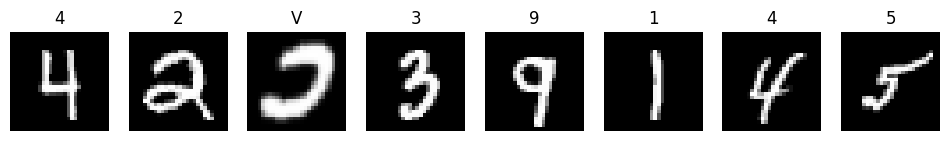

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))
for i, img in enumerate(char_images):
    plt.subplot(1, len(char_images), i+1)
    plt.imshow(img.reshape(28,28), cmap='gray')
    plt.title(plate_text[i])
    plt.axis('off')
plt.show()

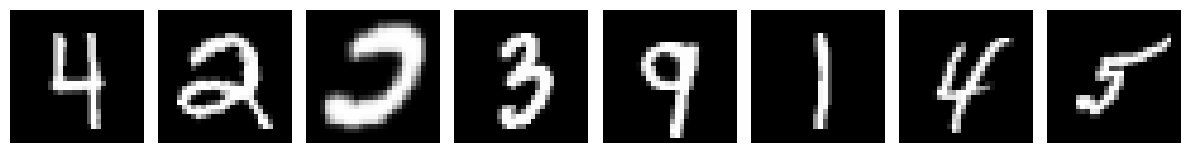

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))
for i, img in enumerate(char_images):
    plt.subplot(1, len(char_images), i+1)
    plt.imshow(img.reshape(28,28), cmap='gray')
    plt.axis('off')   # tắt toàn bộ trục
plt.tight_layout()
plt.show()